# Two-Dimensional Variational Mode Decomposition (2D-VMD)

> **Original paper**: Dragomiretskiy, K. & Zosso, D. (2015). *Two-Dimensional Variational Mode Decomposition*. Energy Minimization Methods in Computer Vision and Pattern Recognition (EMMCVPR), LNCS 8932, pp. 197–208.
> MATLAB reference: [Two-dimensional variational mode decomposition](https://www.mathworks.com/matlabcentral/fileexchange/45918-two-dimensional-variational-mode-decomposition)

This notebook introduces the mathematical foundations of **2D-VMD** and reproduces the paper’s synthetic experiments with PySDKit. Test images come from `pysdkit.data` (`test_grayscale`, `test_univariate_image`).

---

## Contents

1. Motivation: from 1D-VMD and 2D-EMD to 2D-VMD
2. 2D analytic signal and directional half-plane spectra
3. Variational model and ADMM solution
4. Algorithm summary and Wiener-filter view
5. PySDKit API overview
6. Experiment 1: Synthetic multi-mode texture (paper Fig. 1)
7. Experiment 2: PySDKit synthetic images
8. Experiment 3: Center frequencies and spectral separation
9. Experiment 4: Role of $K$, $\alpha$, and the DC mode
10. Experiment 5: Noise robustness with $\tau=0$
11. Summary


## 1. Motivation: from 1D-VMD and 2D-EMD to 2D-VMD

### 1.1 Why decompose images into oscillatory modes?

Many images are mixtures of **directional, band-limited patterns**: textures, microscopy of peptide $\beta$-sheets, overlapping wave-like structures, etc. The goal of 2D-VMD is to recover a small number of **2D intrinsic mode functions (IMFs)** — AM–FM patterns that are compact around unknown center frequencies $\boldsymbol{\omega}_k\in\mathbb{R}^2$ — such that their sum reconstructs the input (exactly or in a least-squares sense).

### 1.2 Limitations of prior approaches

| Family | Idea | Main issue |
|--------|------|------------|
| 2D-EMD / BEMD | Recursive envelope sifting in space | No exact model; sensitive to extrema, interpolation, noise |
| Fixed frames (Gabor, wavelets, curvelets, …) | Rigid spectral tiling | Not adaptive; one physical pattern may split across bands |
| Synchrosqueezing / 2D-EWT | Adaptive wavelets / reassignment | Still tied to a chosen frame / partition |

### 1.3 What 2D-VMD contributes

Dragomiretskiy & Zosso’s **1D-VMD** cast mode extraction as a concurrent variational problem based on Wiener filtering, the Hilbert analytic signal, and demodulation. **2D-VMD** extends that construction:

- modes are extracted **concurrently** (non-recursive);
- each mode is compact around a **2D center frequency** $\boldsymbol{\omega}_k$;
- bandwidth is measured after building a **2D analytic signal** (half-plane spectrum) and shifting it to baseband;
- the same ADMM / dual-ascent structure as 1D-VMD is used, with few user parameters ($K$, $\alpha$, $\tau$, …).


## 2. 2D analytic signal and directional half-plane spectra

### 2.1 Reminder: 1D analytic signal

In 1D, the analytic signal is
$$
f_{\mathrm{AS}}(t)=f(t)+j\,\mathcal{H}\{f\}(t),
$$
equivalently, in Fourier domain, negative frequencies are suppressed (paper Eq. (4)). This unilateral spectrum makes frequency shifting by complex modulation straightforward.

### 2.2 Half-plane analytic signal in 2D

In 2D, “negative frequencies” are replaced by a **half-plane relative to the mode’s center frequency** $\boldsymbol{\omega}_k$ (paper Eq. (5)):
$$
\hat u_{\mathrm{AS},k}(\boldsymbol{\omega})
=
\bigl(1+\mathrm{sgn}(\langle\boldsymbol{\omega},\boldsymbol{\omega}_k\rangle)\bigr)\,
\hat u_k(\boldsymbol{\omega}).
$$
Equivalently, in space (paper Eq. (6)), the transform acts line-wise along the direction of $\boldsymbol{\omega}_k$. The real image mode is recovered by taking the real part after an inverse Fourier transform.

This half-plane construction is the key geometric ingredient that lets 2D-VMD inherit the demodulation / bandwidth idea of 1D-VMD.


## 3. Variational model and ADMM solution

### 3.1 Constrained problem (paper Eq. (7))

$$
\min_{\{u_k\},\{\boldsymbol{\omega}_k\}}
\sum_k
\alpha_k
\left\|
\nabla
\Big[
u_{\mathrm{AS},k}(\mathbf{x})\,e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}
\Big]
\right\|_2^2
\quad\text{s.t.}\quad
\sum_k u_k(\mathbf{x})=f(\mathbf{x}).
$$

Interpretation:

1. build the 2D analytic signal of mode $k$;
2. shift its spectrum to baseband by $e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}$;
3. penalize the squared $H^1$ smoothness (bandwidth) of that demodulated field;
4. enforce exact (or soft) reconstruction of $f$.

### 3.2 Augmented Lagrangian (paper Eq. (8))

$$
\begin{aligned}
\mathcal{L}
&=
\sum_k\alpha_k
\Big\|
\nabla\big[u_{\mathrm{AS},k}e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}\big]
\Big\|_2^2
+
\Big\|f-\sum_k u_k\Big\|_2^2
+
\big\langle\lambda,\,f-\sum_k u_k\big\rangle.
\end{aligned}
$$

### 3.3 ADMM updates

**(1) Mode update — Wiener filter on the half-plane (paper Eq. (16)/(24))**

$$
\hat u_k^{n+1}(\boldsymbol{\omega})
=
\frac{
\hat f(\boldsymbol{\omega})
-
\sum_{i\neq k}\hat u_i(\boldsymbol{\omega})
+
\hat\lambda(\boldsymbol{\omega})/2
}{
1+2\alpha_k\,|\boldsymbol{\omega}-\boldsymbol{\omega}_k^n|^2
}
\qquad\text{for }\boldsymbol{\omega}\in\Omega_k=\{\boldsymbol{\omega}:\langle\boldsymbol{\omega},\boldsymbol{\omega}_k\rangle\ge 0\},
$$
and the opposite half-plane is completed by Hermitian symmetry / taking the real part in space.

**(2) Center-frequency update — spectral center of gravity (paper Eq. (21)/(25))**

$$
\boldsymbol{\omega}_k^{n+1}
=
\frac{
\int_{\Omega_k}\boldsymbol{\omega}\,|\hat u_k(\boldsymbol{\omega})|^2\,\mathrm{d}\boldsymbol{\omega}
}{
\int_{\Omega_k}|\hat u_k(\boldsymbol{\omega})|^2\,\mathrm{d}\boldsymbol{\omega}
}.
$$

**(3) Dual ascent (paper Eq. (22)/(27))**

$$
\hat\lambda^{n+1}
=
\hat\lambda^n
+
\tau\Big(\hat f-\sum_k\hat u_k^{n+1}\Big).
$$

Under strong noise, choose $\tau=0$ so the quadratic fidelity term acts as a denoising prior (same recommendation as in 1D-VMD).


## 4. Algorithm summary and Wiener-filter view

Paper Algorithm 1 iterates, for each mode $k$:

1. build the Fourier Hilbert mask $H_k(\boldsymbol{\omega})=1+\mathrm{sgn}(\langle\boldsymbol{\omega}_k,\boldsymbol{\omega}\rangle)$;
2. update $\hat u_{\mathrm{AS},k}$ by the Wiener filter on that half-plane;
3. update $\boldsymbol{\omega}_k$ as the power-spectrum barycenter;
4. retrieve $u_k=\Re\{\mathcal{F}^{-1}\hat u_{\mathrm{AS},k}\}$;
5. dual-ascend $\hat\lambda$.

Because the mode update is a **narrowband Wiener filter** centered at $\boldsymbol{\omega}_k$, a larger $\alpha$ yields sharper spectral separation — but $\boldsymbol{\omega}_k$ must already be near the true tone, otherwise the filter may miss it. Random half-plane initialization of $\boldsymbol{\omega}_k$ (paper §3.3) is the usual automated choice.


## 5. PySDKit API overview

```python
from pysdkit import VMD2D
from pysdkit.data import test_grayscale, test_univariate_image

img = test_grayscale()                      # (H, W)
vmd = VMD2D(K=5, alpha=1000, tau=0.25, DC=True, init="random", tol=1e-6, max_iter=520)
modes = vmd.fit_transform(img)              # (H, W, K)
modes, u_hat, omega = vmd.fit_transform(img, return_all=True)
```

| Parameter | Meaning |
|-----------|---------|
| `K` | Number of 2D modes |
| `alpha` | Bandwidth / Wiener concentration penalty |
| `tau` | Dual step; use `0` under strong noise |
| `DC` | Keep the first mode at $\boldsymbol{\omega}=(0,0)$ |
| `init` | `"random"` (half-plane) or `"zero"` (radial spread) |
| `tol` / `max_iter` | Convergence controls |
| `random_seed` | Seed for random $\boldsymbol{\omega}_k$ initialization |

**Input / output shapes**

- input image: `(H, W)`
- modes: `(H, W, K)`
- `omega`: history of shape `(max_iter, 2, K)` with Cartesian frequency coordinates


Paper synthetic texture shape: (256, 256)


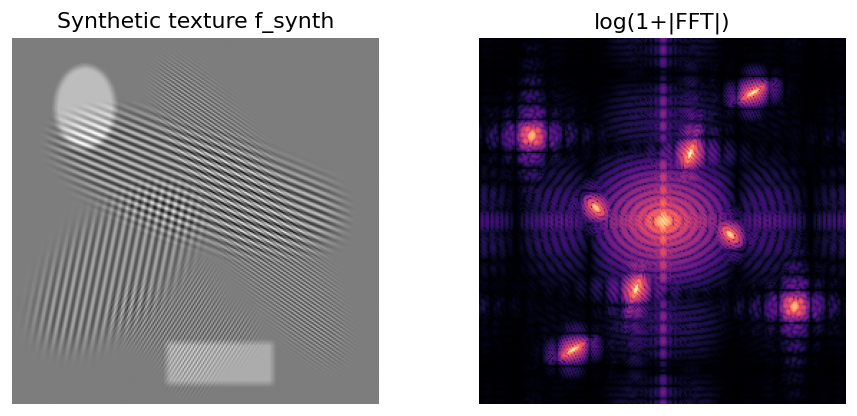

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift

from pysdkit import VMD2D
from pysdkit.data import test_grayscale, test_univariate_image, get_meshgrid_2D
from pysdkit.plot import plot_grayscale_image, plot_grayscale_spectrum

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": False,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float)
    est = np.asarray(est, dtype=float)
    return np.linalg.norm(est - ref) / (np.linalg.norm(ref) + 1e-16)


def show_modes(modes, titles=None, cmap="gray", vmax=None):
    # modes: (H, W, K)
    K = modes.shape[2]
    fig, axs = plt.subplots(1, K, figsize=(2.4 * K, 2.6))
    if K == 1:
        axs = [axs]
    for k in range(K):
        lim = vmax if vmax is not None else np.percentile(np.abs(modes[:, :, k]), 99)
        axs[k].imshow(modes[:, :, k], cmap=cmap, vmin=-lim, vmax=lim)
        axs[k].set_title(titles[k] if titles else f"Mode {k+1}")
        axs[k].axis("off")
    plt.tight_layout()
    return fig, axs


def spectrum_mag(img):
    return np.abs(fftshift(fft2(img)))


def final_omega(omega):
    # omega: (max_iter, 2, K) -> last written (2, K)
    for i in range(omega.shape[0] - 1, -1, -1):
        if np.any(omega[i] != 0) or i == 0:
            return np.asarray(omega[i], dtype=float)
    return np.asarray(omega[-1], dtype=float)


img = test_grayscale()
print("Paper synthetic texture shape:", None if img is None else img.shape)
fig, axs = plt.subplots(1, 2, figsize=(8, 3.6))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Synthetic texture f_synth")
axs[0].axis("off")
axs[1].imshow(np.log1p(spectrum_mag(img)), cmap="magma")
axs[1].set_title("log(1+|FFT|)")
axs[1].axis("off")
plt.tight_layout()
plt.show()

## 6. Experiment 1: Synthetic multi-mode texture (paper Fig. 1)

Paper §3.1: a $256\times 256$ synthetic image composed of spatially overlapping ellipses/rectangle with **different periodicities and directions** (courtesy of J. Gilles). Modes are intentionally narrowband and well isolated in the spectrum.

**Paper parameters:** $\alpha=1000$, $K=5$ (about 520 iterations in the original MATLAB run).

The first mode is the **DC / solid shapes**; the remaining modes recover the patterned ellipses. Sharp edges of solid regions are not band-limited, so the DC mode is a smoothed version and lower-frequency modes may carry residual boundary energy.


modes shape (H, W, K): (256, 256, 5)
relative reconstruction error: 0.7038401698553316
final center frequencies omega (fx, fy) per mode:
  mode 1: (+0.0000, +0.0000)
  mode 2: (+0.3581, +0.2327)
  mode 3: (+0.1823, +0.0365)
  mode 4: (-0.2451, +0.3501)
  mode 5: (-0.0729, +0.1816)


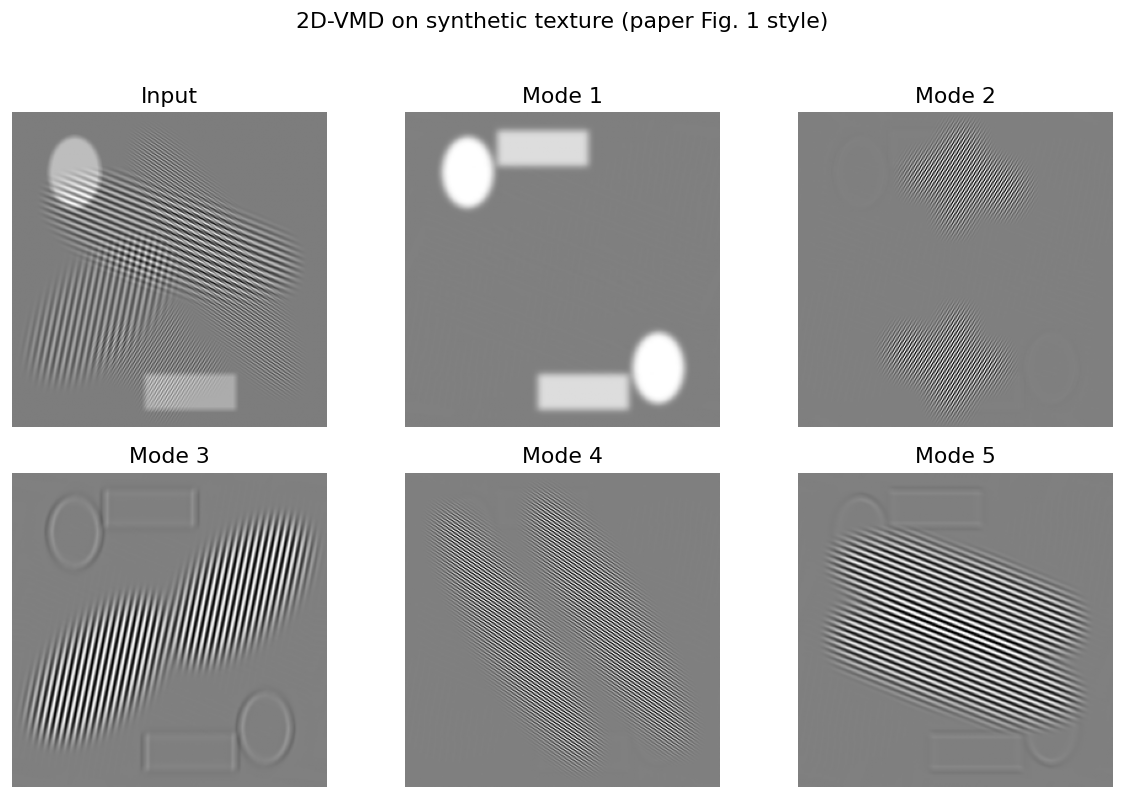

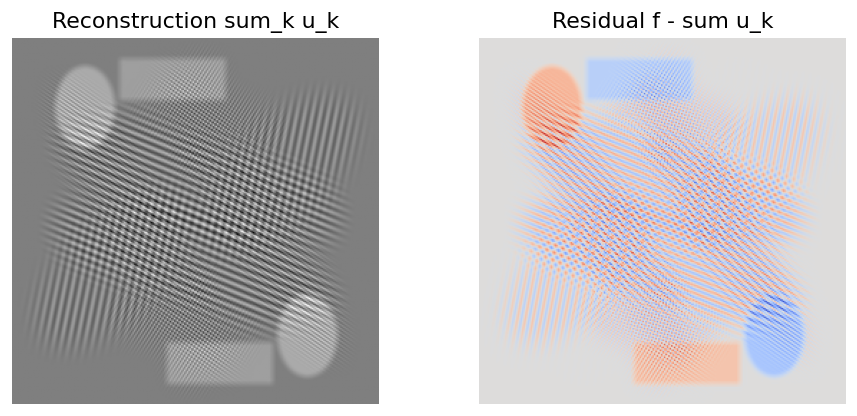

In [2]:
# Paper Fig. 1 settings (max_iter reduced slightly for notebook runtime;
# raise to ~520 for a closer match to the original MATLAB experiment).
vmd = VMD2D(
    K=5,
    alpha=1000,
    tau=0.25,
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=300,
    random_seed=42,
)
modes, u_hat, omega = vmd.fit_transform(img, return_all=True)
recon = modes.sum(axis=2)
w = final_omega(omega)

print("modes shape (H, W, K):", modes.shape)
print("relative reconstruction error:", relative_error(img, recon))
print("final center frequencies omega (fx, fy) per mode:")
for k in range(modes.shape[2]):
    print(f"  mode {k+1}: ({w[0, k]:+.4f}, {w[1, k]:+.4f})")

fig, axs = plt.subplots(2, 3, figsize=(10, 6.5))
axs = axs.ravel()
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Input")
axs[0].axis("off")
for k in range(5):
    lim = np.percentile(np.abs(modes[:, :, k]), 99)
    axs[k + 1].imshow(modes[:, :, k], cmap="gray", vmin=-lim, vmax=lim)
    axs[k + 1].set_title(f"Mode {k+1}")
    axs[k + 1].axis("off")
plt.suptitle("2D-VMD on synthetic texture (paper Fig. 1 style)", y=1.02)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(8, 3.6))
axs[0].imshow(recon, cmap="gray")
axs[0].set_title("Reconstruction sum_k u_k")
axs[0].axis("off")
axs[1].imshow(img - recon, cmap="coolwarm")
axs[1].set_title("Residual f - sum u_k")
axs[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Experiment 2: PySDKit synthetic images

`pysdkit.data.test_univariate_image(case=...)` provides additional separable / directional mixtures on a meshgrid (cases 1–7). They are convenient for controlling scale and for quick demos.

Below we decompose **case 1**
$$
\sin(4x)+\sin(4y)+\sin(x)+\sin(y)+\cos(x/24)+\cos(y/24)
$$
(normalized), which mixes a fast oscillation, a slower oscillation, and a very smooth trend — a natural $K=3$ problem with `DC=True`.


case-1 image shape: (128, 128)
relative recon. error: 0.32469492591659654


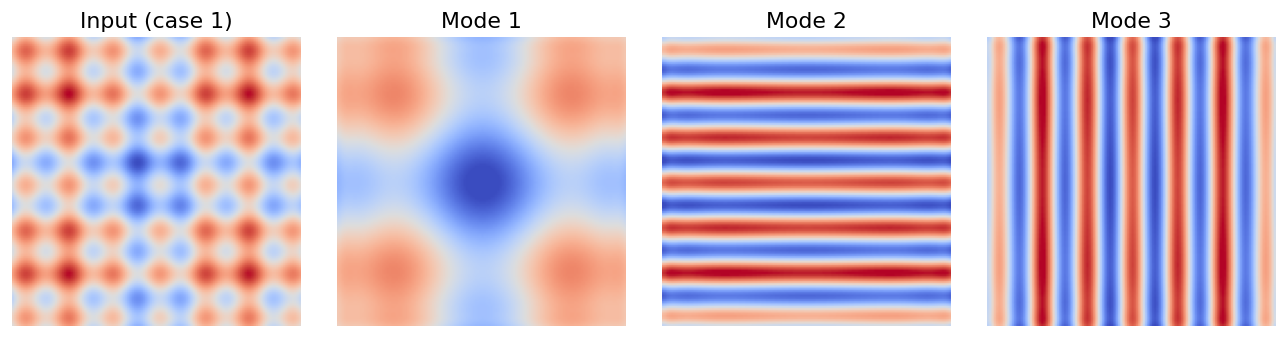

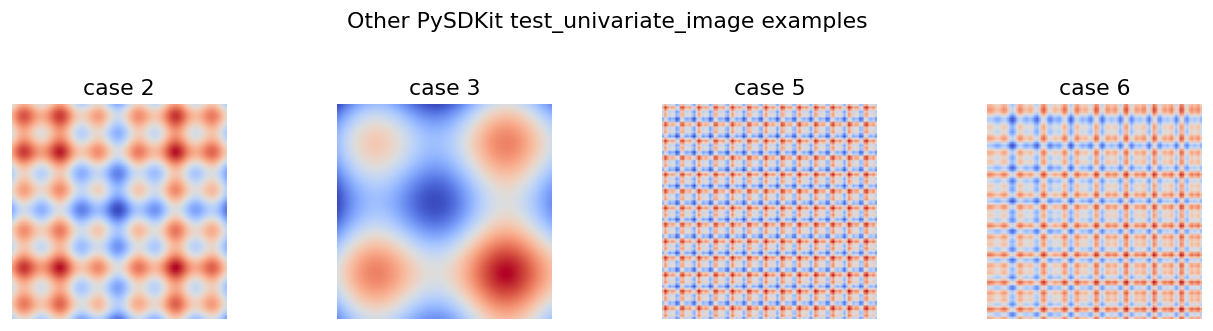

In [3]:
img1 = test_univariate_image(case=1, low=0, high=10, sampling_rate=128)
print("case-1 image shape:", img1.shape)

vmd1 = VMD2D(
    K=3,
    alpha=2000,
    tau=0.25,
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=250,
    random_seed=0,
)
modes1 = vmd1.fit_transform(img1)
print("relative recon. error:", relative_error(img1, modes1.sum(2)))

fig, axs = plt.subplots(1, 4, figsize=(11, 2.8))
axs[0].imshow(img1, cmap="coolwarm")
axs[0].set_title("Input (case 1)")
axs[0].axis("off")
for k in range(3):
    lim = np.percentile(np.abs(modes1[:, :, k]), 99)
    axs[k + 1].imshow(modes1[:, :, k], cmap="coolwarm", vmin=-lim, vmax=lim)
    axs[k + 1].set_title(f"Mode {k+1}")
    axs[k + 1].axis("off")
plt.tight_layout()
plt.show()

# Optional: browse a few other built-in cases
fig, axs = plt.subplots(1, 4, figsize=(11, 2.6))
for i, case in enumerate([2, 3, 5, 6]):
    im = test_univariate_image(case=case, sampling_rate=96)
    axs[i].imshow(im, cmap="coolwarm")
    axs[i].set_title(f"case {case}")
    axs[i].axis("off")
plt.suptitle("Other PySDKit test_univariate_image examples", y=1.05)
plt.tight_layout()
plt.show()

## 8. Experiment 3: Center frequencies and spectral separation

We visualize each mode’s Fourier magnitude and overlay the estimated $\boldsymbol{\omega}_k$. Successful 2D-VMD places each directional tone near its own spectral blob (paper Figs. 1–2, bottom-left spectra).


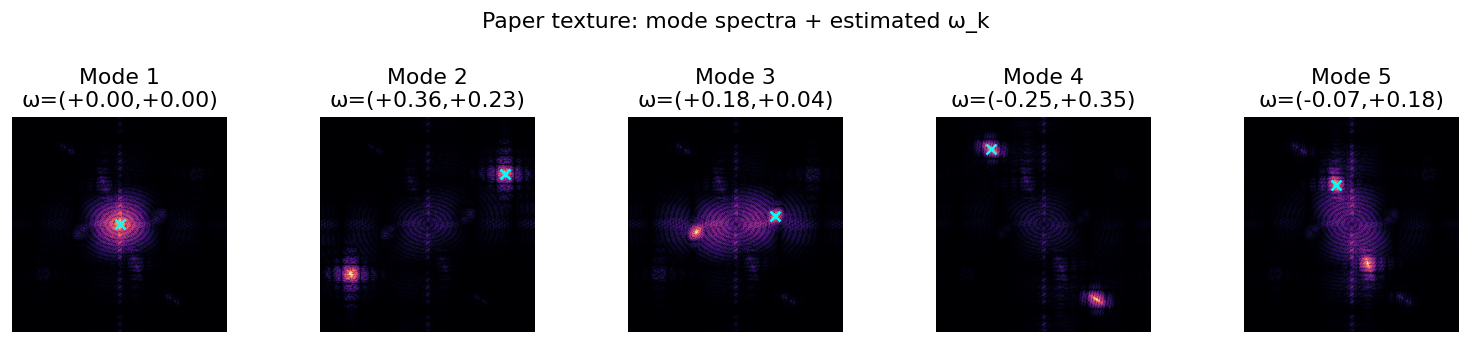

Normalized mode energies: [0.193 0.065 0.107 0.233 0.402]


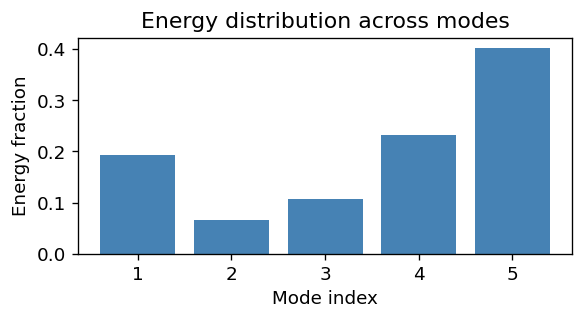

In [4]:
def plot_mode_spectra(modes, omega_2k, title="Mode spectra"):
    K = modes.shape[2]
    fig, axs = plt.subplots(1, K, figsize=(2.6 * K, 2.7))
    if K == 1:
        axs = [axs]
    for k in range(K):
        S = np.log1p(spectrum_mag(modes[:, :, k]))
        axs[k].imshow(S, cmap="magma", origin="lower")
        # omega is in normalized Cartesian coords roughly in [-0.5, 0.5];
        # map to pixel indices of the shifted FFT.
        H, W = modes.shape[:2]
        cx, cy = W / 2.0, H / 2.0
        px = cx + omega_2k[0, k] * W
        py = cy + omega_2k[1, k] * H
        axs[k].scatter([px], [py], c="cyan", s=36, marker="x", linewidths=1.5)
        axs[k].set_title(f"Mode {k+1}\nω=({omega_2k[0,k]:+.2f},{omega_2k[1,k]:+.2f})")
        axs[k].axis("off")
    plt.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()


plot_mode_spectra(modes, w, title="Paper texture: mode spectra + estimated ω_k")

# Energy share of each mode
E = np.array([np.sum(modes[:, :, k] ** 2) for k in range(modes.shape[2])])
E = E / E.sum()
print("Normalized mode energies:", np.round(E, 3))
fig, ax = plt.subplots(figsize=(5, 2.8))
ax.bar(np.arange(1, len(E) + 1), E, color="steelblue")
ax.set_xlabel("Mode index")
ax.set_ylabel("Energy fraction")
ax.set_title("Energy distribution across modes")
plt.tight_layout()
plt.show()

## 9. Experiment 4: Role of $K$, $\alpha$, and the DC mode

### 9.1 DC mode (`DC=True`)

When solid / slowly varying regions are present (paper synthetic image), keeping mode 1 at $\boldsymbol{\omega}=(0,0)$ helps isolate the trend. We demonstrate this on a toy DC + single tone image (as in the unit tests).

### 9.2 Bandwidth weight $\alpha$

Paper §3.3: large $\alpha$ sharpens the Wiener filter (better separation if $\boldsymbol{\omega}_k$ is well placed); small $\alpha$ lets $\boldsymbol{\omega}_k$ migrate more freely but softens separation.


DC mode MAE vs true DC: 0.06653413839188715
relative recon. error: 0.007876402632538264


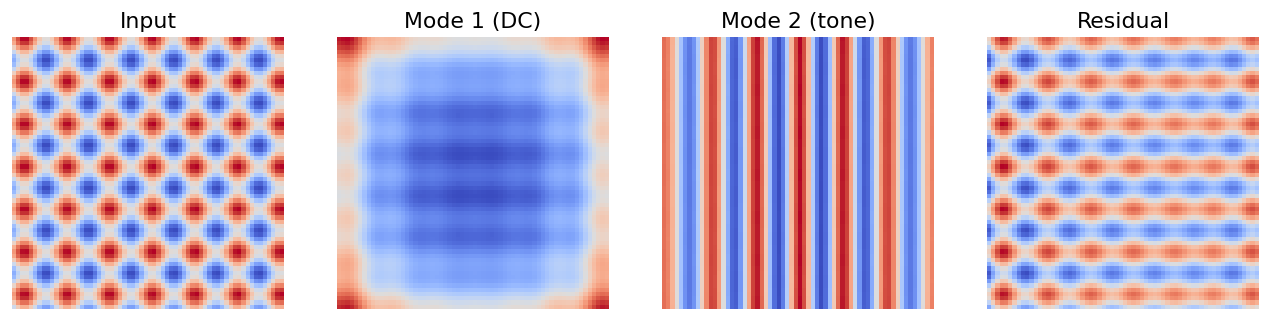

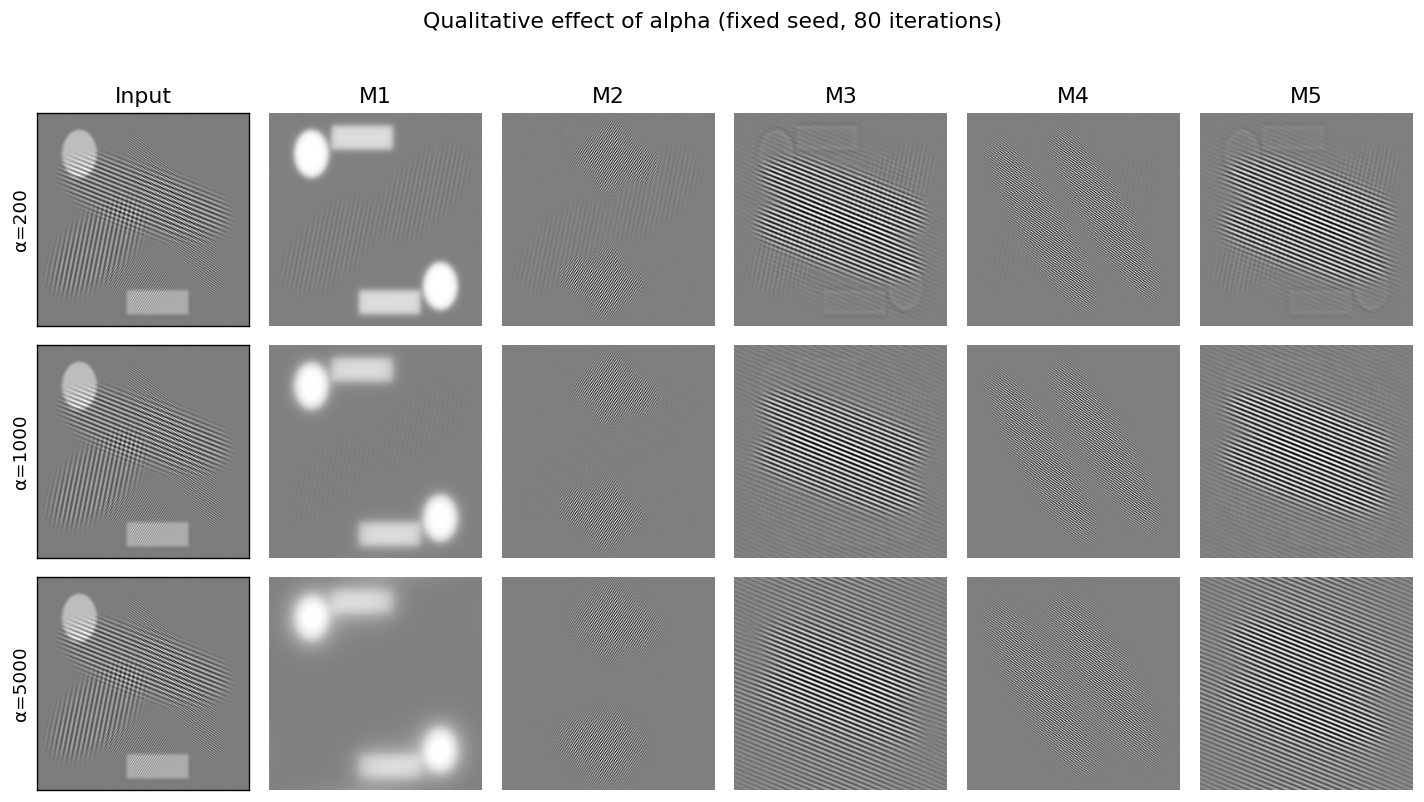

In [5]:
size = 64
x, y = get_meshgrid_2D(low=0, high=2 * np.pi, sampling_rate=size)
DC = 100.0 * np.ones((size, size))
tone = np.sin(2 * np.pi * x) + np.cos(2 * np.pi * y)
toy = DC + tone

vmd_dc = VMD2D(
    K=2,
    alpha=5000,
    tau=0.0,
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=400,
    random_seed=1,
)
u_dc = vmd_dc.fit_transform(toy)
print("DC mode MAE vs true DC:", np.mean(np.abs(u_dc[:, :, 0] - DC)))
print("relative recon. error:", relative_error(toy, u_dc.sum(2)))

fig, axs = plt.subplots(1, 4, figsize=(11, 2.7))
for ax, im, title in zip(
    axs,
    [toy, u_dc[:, :, 0], u_dc[:, :, 1], toy - u_dc.sum(2)],
    ["Input", "Mode 1 (DC)", "Mode 2 (tone)", "Residual"],
):
    ax.imshow(im, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Effect of alpha on the paper texture (fewer iterations for a quick comparison)
alphas = [200, 1000, 5000]
fig, axs = plt.subplots(len(alphas), 6, figsize=(12, 2.2 * len(alphas)))
for i, a in enumerate(alphas):
    v = VMD2D(
        K=5,
        alpha=a,
        tau=0.0,
        DC=True,
        init="random",
        tol=1e-5,
        max_iter=80,
        random_seed=42,
    )
    u = v.fit_transform(img)
    axs[i, 0].imshow(img, cmap="gray")
    axs[i, 0].set_ylabel(f"α={a}")
    axs[i, 0].set_title("Input" if i == 0 else "")
    axs[i, 0].set_xticks([])
    axs[i, 0].set_yticks([])
    for k in range(5):
        lim = np.percentile(np.abs(u[:, :, k]), 99)
        axs[i, k + 1].imshow(u[:, :, k], cmap="gray", vmin=-lim, vmax=lim)
        axs[i, k + 1].set_title(f"M{k+1}" if i == 0 else "")
        axs[i, k + 1].axis("off")
plt.suptitle("Qualitative effect of alpha (fixed seed, 80 iterations)", y=1.02)
plt.tight_layout()
plt.show()

## 10. Experiment 5: Noise robustness with $\tau=0$

As in 1D-VMD, setting $\tau=0$ disables dual ascent and lets the quadratic fidelity term absorb noise. We corrupt the Gilles texture with Gaussian noise and check that the main directional patterns remain separable.


Approx. SNR: 9.1 dB
relative error vs clean image: 0.7113641239733511
relative error vs noisy image: 0.7383873212620572


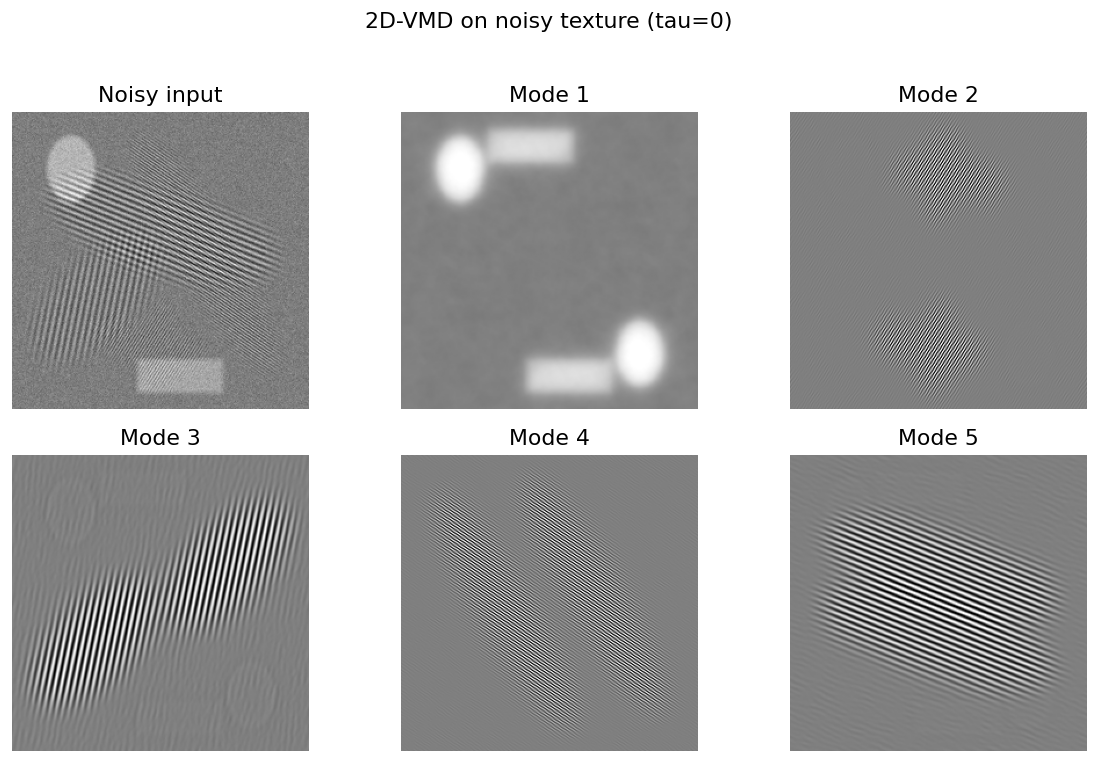

In [6]:
rng = np.random.default_rng(0)
noise_std = 0.35 * np.std(img)
noisy = img + noise_std * rng.standard_normal(img.shape)
snr = 10 * np.log10(np.var(img) / np.var(noisy - img))
print(f"Approx. SNR: {snr:.1f} dB")

vmd_n = VMD2D(
    K=5,
    alpha=1000,
    tau=0.0,  # noise-slack
    DC=True,
    init="random",
    tol=1e-6,
    max_iter=250,
    random_seed=42,
)
modes_n = vmd_n.fit_transform(noisy)
recon_n = modes_n.sum(2)
print("relative error vs clean image:", relative_error(img, recon_n))
print("relative error vs noisy image:", relative_error(noisy, recon_n))

fig, axs = plt.subplots(2, 3, figsize=(10, 6.2))
axs = axs.ravel()
axs[0].imshow(noisy, cmap="gray")
axs[0].set_title("Noisy input")
axs[0].axis("off")
for k in range(5):
    lim = np.percentile(np.abs(modes_n[:, :, k]), 99)
    axs[k + 1].imshow(modes_n[:, :, k], cmap="gray", vmin=-lim, vmax=lim)
    axs[k + 1].set_title(f"Mode {k+1}")
    axs[k + 1].axis("off")
plt.suptitle("2D-VMD on noisy texture (tau=0)", y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary

1. **Motivation**: 2D-VMD replaces recursive 2D-EMD / fixed frames with a **concurrent variational** decomposition into directional, band-limited modes.
2. **Model**: bandwidth of each mode is the $H^1$ norm of its **half-plane analytic signal** after demodulation by $e^{-j\langle\boldsymbol{\omega}_k,\mathbf{x}\rangle}$ (paper Eq. (7)).
3. **Algorithm**: ADMM with Wiener mode updates, spectral barycenter updates for $\boldsymbol{\omega}_k$, and dual ascent for $\lambda$ (Algorithm 1).
4. **Experiments reproduced / adapted here**:
   - Gilles synthetic texture via `test_grayscale()` (paper Fig. 1; $\alpha=1000$, $K=5$);
   - additional meshgrid mixtures via `test_univariate_image`;
   - DC extraction, $\alpha$ sensitivity, and noisy decomposition with $\tau=0$.
5. **Practical tips**:
   - prefer `init="random"` with a fixed `random_seed` for reproducibility;
   - use `DC=True` when a solid / trend component is expected;
   - increase `max_iter` (paper: ~520 for the $256\times 256$ synthetic image) if modes look mixed;
   - the peptide $\beta$-sheet experiment in the paper ($512\times 512$, $\alpha=5000$, $K=5$) follows the same API once the STM image is available.

### Further reading

- Dragomiretskiy & Zosso, EMMCVPR / LNCS 8932, 2015 (this paper — 2D-VMD)
- Dragomiretskiy & Zosso, *IEEE TSP*, 2014 (1D-VMD)
- Gilles et al., related texture / empirical-wavelet image decompositions

### One-liner with PySDKit

```python
from pysdkit import VMD2D
from pysdkit.data import test_grayscale
modes = VMD2D(K=5, alpha=1000, tau=0.25, DC=True, init="random").fit_transform(test_grayscale())
```
